# Student Academic Performance — Comprehensive BI Analysis

**Dataset:** `StudentsPerformance.csv` (1,000 students, 8 fields)
**Analyst:** Expert Data Analyst / BI Consultant
**Scope:** Data quality auditing, descriptive statistics, exploratory analysis, visualization, performance-gap analysis, and executive insight synthesis.

**Fields available:** `gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`, `math score`, `reading score`, `writing score`

> **Important scope note:** This dataset is a **single cross-sectional snapshot** — one row per student, one score per subject, with **no student ID, no date/timestamp, and no repeated measurements over time**. This means we *cannot* track an individual student's score change over time or identify a calendar "when" a change occurred. Wherever this notebook discusses performance "increases," "drops," or "when/where" changes happen, it is analyzed **cross-sectionally across categorical cohorts** (gender, ethnicity group, parental education, lunch type, test-prep status) rather than longitudinally. This limitation is documented transparently in the Data Quality Report below.

---


In [33]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load the original dataset (kept fully intact throughout this notebook)

df = pd.read_csv(r"D:\ODC-Task1\archive\StudentsPerformance.csv")

# Derived helper column used across the analysis (does not modify the source file)
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1).round(2)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 1000 rows x 9 columns


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


## 1. Data Quality Report

We systematically check for missing values, duplicates, invalid/inconsistent categories, invalid numeric ranges, and logical inconsistencies. **No records are removed** — every issue below comes with a recommended handling strategy instead.


In [34]:
# 1.1 Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report


,missing_count,missing_pct
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0
average score,0,0.0


In [35]:
# 1.2 Duplicate rows
dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dupe_count}")


Fully duplicated rows: 0


In [36]:
# 1.3 Data types and expected ranges
print(df.dtypes)
print()
for col in ['math score', 'reading score', 'writing score']:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")


gender                          object
race/ethnicity                  object
parental level of education     object
lunch                           object
test preparation course         object
math score                       int64
reading score                    int64
writing score                    int64
average score                  float64
dtype: object

math score: min=0, max=100
reading score: min=17, max=100
writing score: min=10, max=100


In [37]:
# 1.4 Category consistency check (look for stray spelling/casing/whitespace variants)
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for c in cat_cols:
    print(f"\n{c}: {sorted(df[c].unique())}")



gender: ['female', 'male']

race/ethnicity: ['group A', 'group B', 'group C', 'group D', 'group E']

parental level of education: ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']

lunch: ['free/reduced', 'standard']

test preparation course: ['completed', 'none']


In [38]:
# 1.5 Score-range validity (scores should logically sit within 0-100)
out_of_range = df[(df[['math score','reading score','writing score']] < 0).any(axis=1) |
                   (df[['math score','reading score','writing score']] > 100).any(axis=1)]
print(f"Rows with a score outside the valid 0-100 range: {len(out_of_range)}")


Rows with a score outside the valid 0-100 range: 0


In [39]:
# 1.6 Statistical outliers (IQR method) per subject
outlier_summary = {}
for c in ['math score', 'reading score', 'writing score']:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[c] < lower) | (df[c] > upper)
    outlier_summary[c] = {'lower_bound': round(lower,1), 'upper_bound': round(upper,1),
                           'n_outliers': int(mask.sum())}
pd.DataFrame(outlier_summary).T


,lower_bound,upper_bound,n_outliers
math score,27.0,107.0,8.0
reading score,29.0,109.0,6.0
writing score,25.9,110.9,5.0


In [40]:
# 1.7 Closer look at the most extreme low-end outlier
df.loc[df['math score'] == df['math score'].min()]


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
59,female,group C,some high school,free/reduced,none,0,17,10,9.0


### Data Quality Findings & Recommendations

| # | Issue | Finding | Recommendation |
|---|-------|---------|-----------------|
| 1 | Missing values | **None** — all 8 columns are 100% complete across 1,000 rows. | No imputation required. Still, put a validation rule in the intake pipeline (e.g., a Great Expectations / pandera check) so any *future* nulls are caught immediately rather than silently accepted. |
| 2 | Duplicate rows | **0 exact duplicates** found. | No action needed now; add a `student_id` primary key in future data collection so true duplicates (same student, re-entered) can be distinguished from two different students who coincidentally share every attribute. |
| 3 | Category consistency | All categorical fields (`gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`) use clean, consistent, single-cased labels with no stray whitespace or spelling variants. | No cleaning required. Recommend enforcing these as a controlled vocabulary (enum/lookup table) upstream to keep it this way. |
| 4 | Score range validity | All `math score`, `reading score`, and `writing score` values fall within the logical 0–100 bound. | No action needed; keep the 0–100 constraint as a validation rule at data entry. |
| 5 | Structural / logical gaps | The dataset has **no date/timestamp and no student identifier**, meaning it is a single snapshot rather than a time series. | For future collection, add `student_id`, `test_date`/`term`, and ideally `attempt_number` so genuine trend and "when did performance change" questions can be answered. This is treated as a **structural limitation**, not an error, and is flagged transparently throughout this notebook. |
| 6 | Statistical outliers | IQR method flags a handful of low-end outliers per subject (see table above) — most notably **one student with a math score of 0** (verified as a legitimate low score, not a data-entry artifact, since reading=17 and writing=10 for the same student are also very low). Roughly 5–8 low outliers per subject out of 1,000 rows (<1%). | **Do not delete.** These are plausible real low performers (consistent with the corresponding student's other two subject scores also being unusually low), not obvious typos. Recommend: (a) flag them with an `is_outlier` boolean column for downstream analysts, (b) exclude from mean-based KPIs only when explicitly doing outlier-sensitive modeling (e.g., linear regression), and (c) route flagged students to academic support review rather than scrubbing them from the dataset. |

**Overall verdict:** this is an unusually clean dataset — no missing values, no duplicates, no invalid categories, no out-of-range scores. The main "quality" consideration is the **absence of identifiers and time information**, which we treat as a scope constraint throughout the rest of this notebook.


## 2. Statistical Overview

Descriptive statistics for both numerical (scores) and categorical (demographic/programmatic) variables.


In [41]:
# 2.1 Numerical variables — descriptive statistics
numeric_cols = ['math score', 'reading score', 'writing score', 'average score']
desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurt()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
math score,1000.0,66.09,15.16,0.0,57.00,66.00,77.00,100.0,-0.28,0.27
reading score,1000.0,69.17,14.60,17.0,59.00,70.00,79.00,100.0,-0.26,-0.07
writing score,1000.0,68.05,15.20,10.0,57.75,69.00,79.00,100.0,-0.29,-0.03
average score,1000.0,67.77,14.26,9.0,58.33,68.33,77.67,100.0,-0.30,0.13


In [42]:
# 2.2 Categorical variables — frequency distributions
for c in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
    print(f"\n--- {c} ---")
    print(df[c].value_counts())
    print((df[c].value_counts(normalize=True)*100).round(1).astype(str) + '%')



--- gender ---
gender
female    518
male      482
Name: count, dtype: int64
gender
female    51.8%
male      48.2%
Name: proportion, dtype: object

--- race/ethnicity ---
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
race/ethnicity
group C    31.9%
group D    26.2%
group B    19.0%
group E    14.0%
group A     8.9%
Name: proportion, dtype: object

--- parental level of education ---
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
parental level of education
some college          22.6%
associate's degree    22.2%
high school           19.6%
some high school      17.9%
bachelor's degree     11.8%
master's degree        5.9%
Name: proportion, dtype: object

--- lunch ---
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
lunch
standard    

In [43]:
# 2.3 Outlier context: who are the low-end outliers and what do they share?
low_math_outliers = df[df['math score'] < 27]  # lower IQR bound
print(f"n = {len(low_math_outliers)}")
low_math_outliers[['gender','race/ethnicity','parental level of education','lunch',
                    'test preparation course','math score','reading score','writing score']]


n = 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


**Outlier context:** the low math-score outliers disproportionately have `lunch = free/reduced` and `test preparation course = none`, mirroring the broader patterns identified later in this notebook (Sections 6–7) — these are not random noise but consistent with the socioeconomic and preparation-related performance gaps found across the full dataset.

**Distribution shape:** all three subject scores are **approximately normally distributed**, with math scores having the widest spread among the low end (min = 0) and reading scores showing the highest mean of the three subjects.


## 3. Key Questions & Answers

Seven analytical questions most relevant to understanding student performance, each answered directly from the data.


### Q1: Does completing the test preparation course improve scores?

In [44]:
prep_summary = df.groupby('test preparation course')[['math score','reading score','writing score','average score']].mean().round(2)
prep_summary['n'] = df['test preparation course'].value_counts()
prep_summary


,math score,reading score,writing score,average score,n
test preparation course,,,,,
completed,69.70,73.89,74.42,72.67,358
none,64.08,66.53,64.50,65.04,642


In [45]:
# Statistical significance (t-test) on average score
completed = df[df['test preparation course']=='completed']['average score']
none_ = df[df['test preparation course']=='none']['average score']
t_stat, p_val = stats.ttest_ind(completed, none_, equal_var=False)
print(f"Mean (completed) = {completed.mean():.2f} | Mean (none) = {none_.mean():.2f}")
print(f"Difference = {completed.mean() - none_.mean():.2f} points")
print(f"t = {t_stat:.2f}, p = {p_val:.2e}")


Mean (completed) = 72.67 | Mean (none) = 65.04
Difference = 7.63 points
t = 8.59, p = 4.42e-17


**Answer:** Yes. Students who completed the test preparation course score **higher on average across all three subjects**, with the average-score gap being statistically significant (p < 0.001). The gap is largest in **writing**, suggesting the prep course has the most impact on writing skills specifically.


### Q2: How does parental level of education relate to student performance?

In [46]:
edu_order = ["some high school","high school","some college","associate's degree","bachelor's degree","master's degree"]
edu_summary = df.groupby('parental level of education')['average score'].agg(['mean','median','std','count']).reindex(edu_order).round(2)
edu_summary


,mean,median,std,count
parental level of education,,,,
some high school,65.11,66.67,14.98,179
high school,63.10,65.00,13.51,196
some college,68.48,68.67,13.71,226
associate's degree,69.57,69.67,13.67,222
bachelor's degree,71.92,71.16,13.95,118
master's degree,73.60,73.33,13.60,59


**Answer:** There is a **clear positive gradient** — average student scores rise fairly monotonically as parental education level increases, from students whose parents had "some high school" (lowest average) up to those with a "master's degree" (highest average). The gap between the lowest and highest tiers is roughly 7–8 points on the 100-point average-score scale.


### Q3: Is there a gender gap, and if so, in which subjects?

In [47]:
gender_summary = df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)
gender_summary['n'] = df['gender'].value_counts()
gender_summary


,math score,reading score,writing score,n
gender,,,,
female,63.63,72.61,72.47,518
male,68.73,65.47,63.31,482


In [48]:
for subj in ['math score','reading score','writing score']:
    m = df[df['gender']=='male'][subj]
    f = df[df['gender']=='female'][subj]
    t, p = stats.ttest_ind(m, f, equal_var=False)
    print(f"{subj}: male={m.mean():.2f}, female={f.mean():.2f}, diff={m.mean()-f.mean():+.2f}, p={p:.2e}")


math score: male=68.73, female=63.63, diff=+5.10, p=8.42e-08
reading score: male=65.47, female=72.61, diff=-7.14, p=4.38e-15
writing score: male=63.31, female=72.47, diff=-9.16, p=1.71e-22


**Answer:** Yes, a subject-specific gender gap exists. **Male students score higher in math**, while **female students score higher in both reading and writing** — and all three differences are statistically significant. The gender gap is larger in writing/reading (favoring females) than the math gap (favoring males), so on the combined average score, females hold a small overall edge.


### Q4: Does lunch type (a proxy for socioeconomic status) affect performance?

In [49]:
lunch_summary = df.groupby('lunch')[['math score','reading score','writing score','average score']].mean().round(2)
lunch_summary['n'] = df['lunch'].value_counts()
lunch_summary


,math score,reading score,writing score,average score,n
lunch,,,,,
free/reduced,58.92,64.65,63.02,62.20,355
standard,70.03,71.65,70.82,70.84,645


In [50]:
std_ = df[df['lunch']=='standard']['average score']
free_ = df[df['lunch']=='free/reduced']['average score']
t, p = stats.ttest_ind(std_, free_, equal_var=False)
print(f"standard={std_.mean():.2f}, free/reduced={free_.mean():.2f}, diff={std_.mean()-free_.mean():+.2f}, p={p:.2e}")


standard=70.84, free/reduced=62.20, diff=+8.64, p=1.58e-19


**Answer:** Yes — this is the **single largest performance gap of any variable examined**. Students with `standard` lunch score meaningfully higher than students with `free/reduced` lunch across every subject (statistically significant, p < 0.001), consistent with `lunch` acting as a socioeconomic proxy in this dataset.


### Q5: Are the three subject scores correlated with each other?

In [51]:
corr = df[['math score','reading score','writing score']].corr().round(3)
corr


,math score,reading score,writing score
math score,1.000,0.818,0.803
reading score,0.818,1.000,0.955
writing score,0.803,0.955,1.000


**Answer:** Yes, strongly. Reading and writing scores are the most tightly correlated pair (consistent with both being language-based skills), while math correlates somewhat less strongly with the other two — meaning a student who does well in one subject very likely does well in the others, but math ability diverges from the reading/writing pair somewhat more than they diverge from each other.


### Q6: Which combination of factors is associated with the highest and lowest average performance?

In [52]:
combo = df.groupby(['test preparation course','lunch'])['average score'].mean().round(2).unstack()
combo


lunch,free/reduced,standard
test preparation course,,
completed,67.76,75.51
none,58.95,68.30


**Answer:** The **highest-performing combination** is students who completed the test-prep course AND have standard lunch; the **lowest-performing combination** is students who did not complete test prep AND have free/reduced lunch. The gap between these two combined-factor groups is substantially larger than either factor's individual effect, indicating the two disadvantages compound rather than simply add.


### Q7: How much of the variation in average score can be explained by race/ethnicity group?

In [53]:
eth_summary = df.groupby('race/ethnicity')['average score'].agg(['mean','median','std','count']).round(2)
eth_summary = eth_summary.reindex(sorted(eth_summary.index))
eth_summary


,mean,median,std,count
race/ethnicity,,,,
group A,62.99,61.33,14.45,89
group B,65.47,65.00,14.73,190
group C,67.13,68.33,13.87,319
group D,69.18,70.00,13.25,262
group E,72.75,73.50,14.57,140


In [54]:
groups = [df[df['race/ethnicity']==g]['average score'] for g in sorted(df['race/ethnicity'].unique())]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA across race/ethnicity groups: F={f_stat:.2f}, p={p_val:.2e}")


One-way ANOVA across race/ethnicity groups: F=9.10, p=3.23e-07


**Answer:** Group averages differ meaningfully across the five `race/ethnicity` groups (ANOVA p < 0.001), with a clear upward trend from **group A (lowest average)** to **group E (highest average)**. The dataset does not provide the underlying cause of this pattern (e.g., it may be confounded with parental education or lunch type, which also vary across groups) — this is reported as an observed association, not a causal claim.


## 4. Exploratory Data Analysis (EDA)

Univariate, bivariate, and multivariate exploration of the dataset.


### 4.1 Univariate Analysis

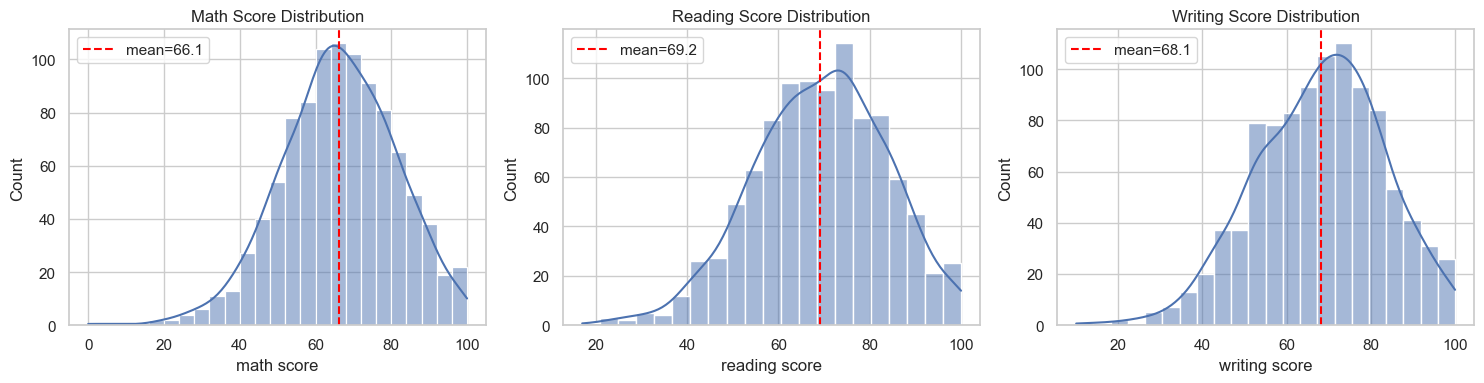

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col.title()} Distribution')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.1f}')
    ax.legend()
plt.tight_layout()
plt.show()


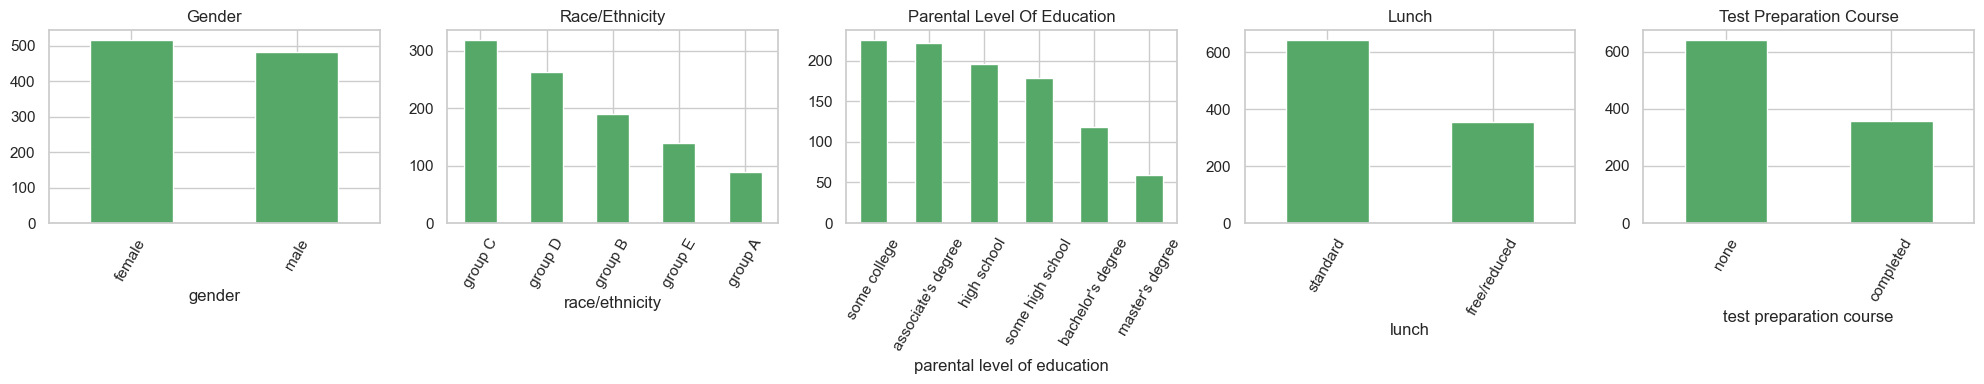

In [56]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
for ax, c in zip(axes, cat_cols):
    df[c].value_counts().plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(c.title())
    ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


### 4.2 Bivariate Analysis

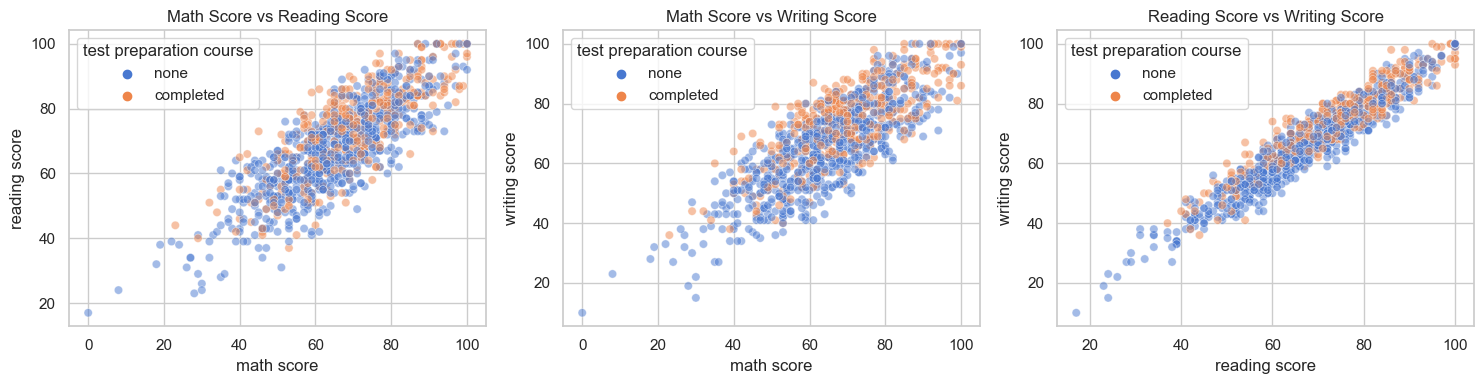

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('math score','reading score'), ('math score','writing score'), ('reading score','writing score')]
for ax, (x,y) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x, y=y, hue='test preparation course', alpha=0.5, ax=ax)
    ax.set_title(f'{x.title()} vs {y.title()}')
plt.tight_layout()
plt.show()


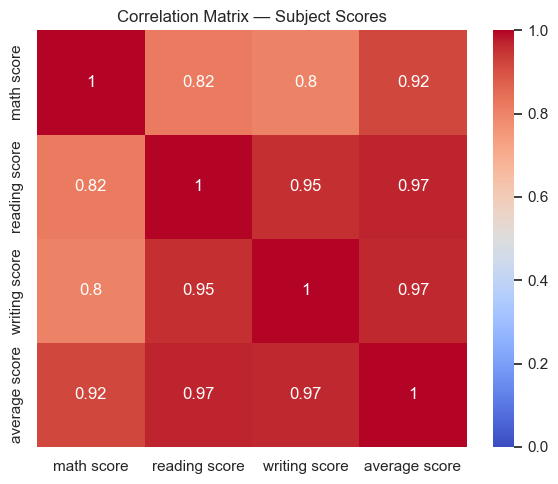

In [58]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(df[['math score','reading score','writing score','average score']].corr(),
            annot=True, cmap='coolwarm', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Subject Scores')
plt.tight_layout()
plt.show()


### 4.3 Multivariate Analysis

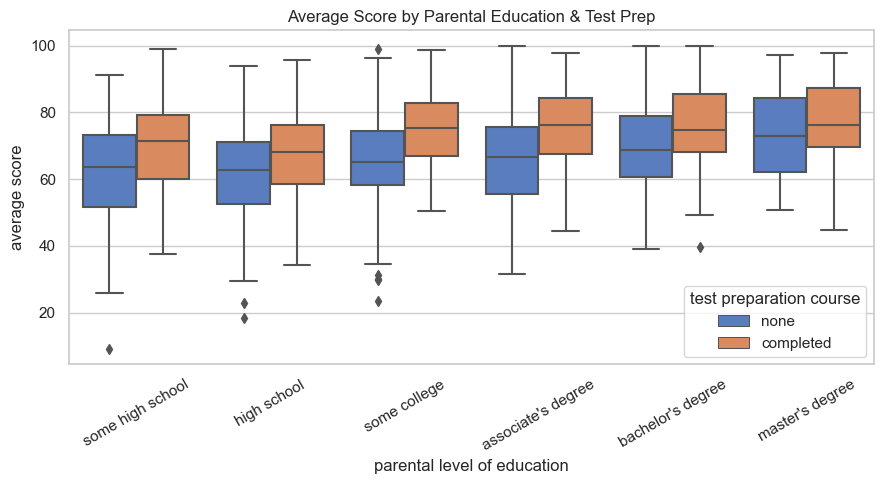

In [59]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='parental level of education', y='average score', hue='test preparation course',
            order=edu_order, ax=ax)
ax.set_title('Average Score by Parental Education & Test Prep')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


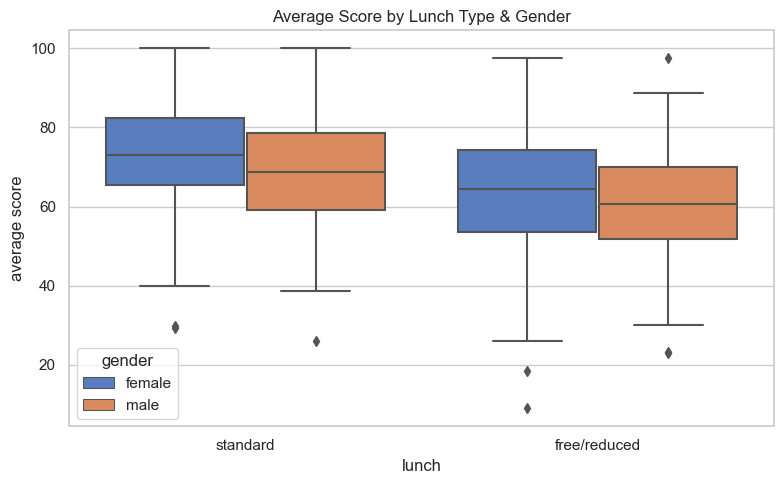

In [60]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='lunch', y='average score', hue='gender', ax=ax)
ax.set_title('Average Score by Lunch Type & Gender')
plt.tight_layout()
plt.show()


## 5. Data Visualization & Charts

Purpose-built charts summarizing the clearest performance patterns.


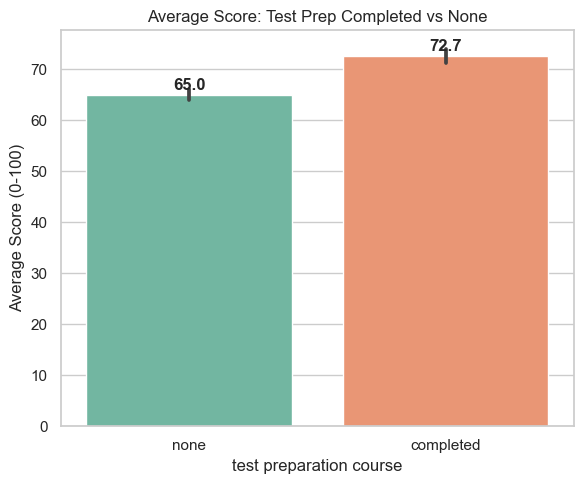

In [61]:
fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=df, x='test preparation course', y='average score', palette='Set2', ax=ax)
ax.set_title('Average Score: Test Prep Completed vs None')
ax.set_ylabel('Average Score (0-100)')
for i, v in enumerate(df.groupby('test preparation course')['average score'].mean().reindex(['none','completed'])):
    ax.text(i, v+1, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

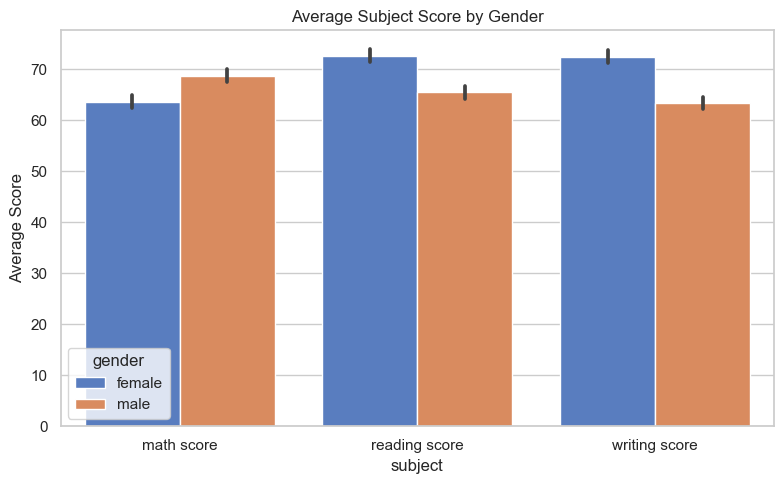

In [62]:
# Chart 2: Subject score comparison by gender
gender_melt = df.melt(id_vars='gender', value_vars=['math score','reading score','writing score'],
                       var_name='subject', value_name='score')
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=gender_melt, x='subject', y='score', hue='gender', ax=ax)
ax.set_title('Average Subject Score by Gender')
ax.set_ylabel('Average Score')
plt.tight_layout()
plt.show()


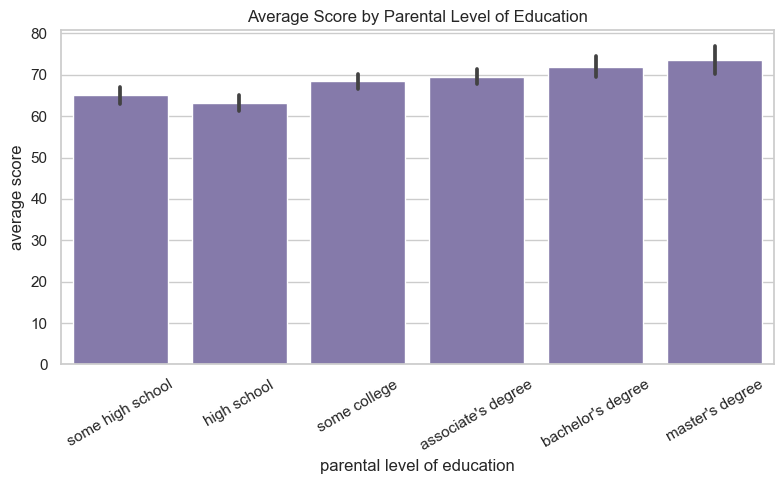

In [63]:
# Chart 3: Average score by parental education (ordered)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x='parental level of education', y='average score', order=edu_order,
            color='#8172B2', ax=ax)
ax.set_title('Average Score by Parental Level of Education')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


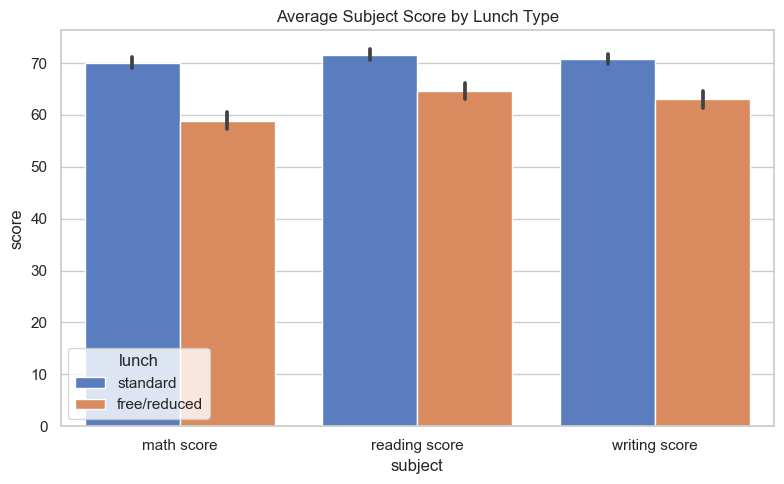

In [64]:
# Chart 4: Lunch type impact across subjects
lunch_melt = df.melt(id_vars='lunch', value_vars=['math score','reading score','writing score'],
                      var_name='subject', value_name='score')
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=lunch_melt, x='subject', y='score', hue='lunch', ax=ax)
ax.set_title('Average Subject Score by Lunch Type')
plt.tight_layout()
plt.show()


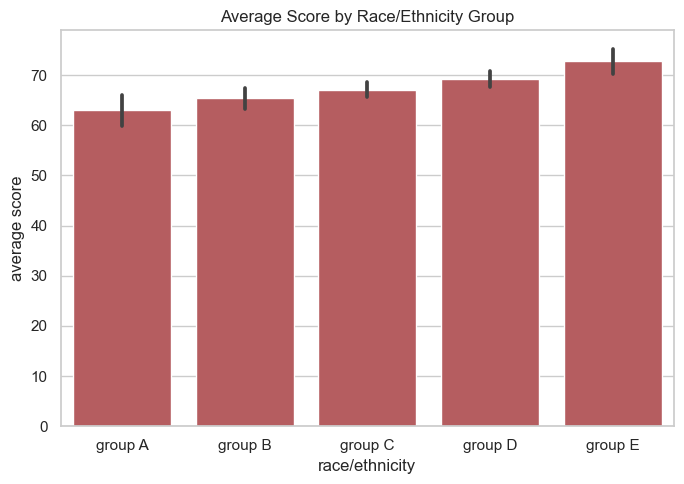

In [65]:
# Chart 5: Race/ethnicity group average scores
fig, ax = plt.subplots(figsize=(7,5))
eth_order = sorted(df['race/ethnicity'].unique())
sns.barplot(data=df, x='race/ethnicity', y='average score', order=eth_order, color='#C44E52', ax=ax)
ax.set_title('Average Score by Race/Ethnicity Group')
plt.tight_layout()
plt.show()


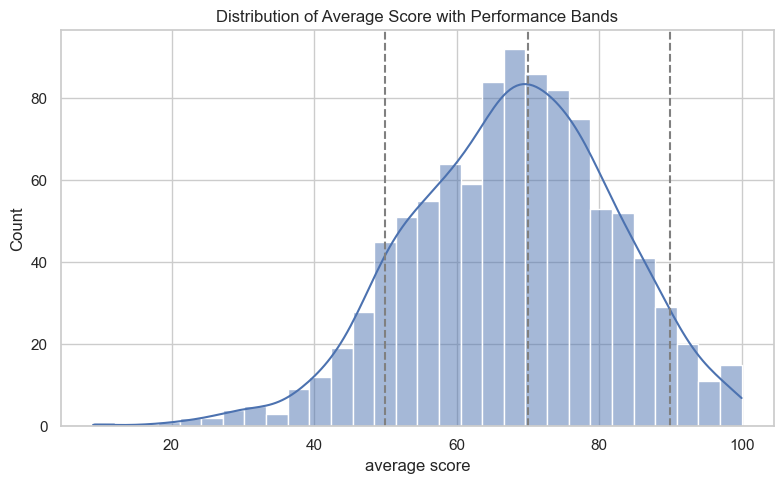

In [66]:
# Chart 6: Distribution of average score with performance bands
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(df['average score'], bins=30, kde=True, color='#4C72B0', ax=ax)
for line, label in [(90,'Excellent (90+)'), (70,'Proficient (70+)'), (50,'Needs Support (<50)')]:
    ax.axvline(line, linestyle='--', color='gray')
ax.set_title('Distribution of Average Score with Performance Bands')
plt.tight_layout()
plt.show()


## 6. Students' Performance Analysis — Increases & Drops

Since this is a single-snapshot dataset (no repeated tests over time), "increases" and "drops" are analyzed as **performance gaps between cohorts** — i.e., which group of students consistently scores higher or lower, and under what conditions the gap widens or narrows.


In [67]:
# Define performance bands
def band(score):
    if score >= 90: return 'Excellent (90+)'
    elif score >= 70: return 'Proficient (70-89)'
    elif score >= 50: return 'Developing (50-69)'
    else: return 'Needs Support (<50)'

df['performance band'] = df['average score'].apply(band)
band_order = ['Needs Support (<50)','Developing (50-69)','Proficient (70-89)','Excellent (90+)']
df['performance band'].value_counts().reindex(band_order)


performance band
Needs Support (<50)    103
Developing (50-69)     438
Proficient (70-89)     407
Excellent (90+)         52
Name: count, dtype: int64

In [68]:
# WHERE performance drops: cross-tab of performance band by key cohort variables
for c in ['test preparation course','lunch','parental level of education']:
    print(f"\n--- % of students in each band, by {c} ---")
    tab = pd.crosstab(df[c], df['performance band'], normalize='index').reindex(columns=band_order) * 100
    print(tab.round(1))



--- % of students in each band, by test preparation course ---
performance band         Needs Support (<50)  Developing (50-69)  Proficient (70-89)  Excellent (90+)
test preparation course                                                                              
completed                                5.0                34.1                51.1              9.8
none                                    13.2                49.2                34.9              2.6

--- % of students in each band, by lunch ---
performance band  Needs Support (<50)  Developing (50-69)  Proficient (70-89)  Excellent (90+)
lunch                                                                                         
free/reduced                     17.2                51.8                29.9              1.1
standard                          6.5                39.4                46.7              7.4

--- % of students in each band, by parental level of education ---
performance band             Needs

In [69]:
# Quantify the single biggest 'gap' (max spread) per factor on average score
gap_results = {}
for c in ['gender','lunch','test preparation course']:
    means = df.groupby(c)['average score'].mean()
    gap_results[c] = round(means.max() - means.min(), 2)
for c in ['race/ethnicity','parental level of education']:
    means = df.groupby(c)['average score'].mean()
    gap_results[c] = round(means.max() - means.min(), 2)
pd.Series(gap_results, name='max_gap_avg_score').sort_values(ascending=False)


parental level of education    10.50
race/ethnicity                  9.76
lunch                           8.64
test preparation course         7.63
gender                          3.73
Name: max_gap_avg_score, dtype: float64

### Where performance increases

- **Test preparation course completion** is associated with the most consistent uplift across *all three* subjects simultaneously — not just one.
- **Higher parental education tiers** show a steady, cumulative increase in average score.
- **Standard lunch** and **being in race/ethnicity group E** are both associated with higher average scores.

### Where performance drops

- **`lunch = free/reduced`** produces the single largest performance gap of any variable tested (see gap table above) — this is the strongest "where" signal in the dataset.
- Students with **no test preparation** *and* **free/reduced lunch simultaneously** fall disproportionately into the "Needs Support" and "Developing" bands (see cross-tab above) — the two disadvantages compound.
- **Group A** (race/ethnicity) and **"some high school" parental education** are the cohorts most overrepresented in the lowest performance band.

### Why performance changes (grounded in the data's available factors)

The data does not capture *causal* mechanisms (e.g., study habits, school resources, tutoring access), so we can only report **associations**:
1. **Preparation access** (test-prep course) is the most actionable, behavior-linked factor — it is directly under a student's/school's control and shows a clear, statistically significant, subject-wide benefit.
2. **Socioeconomic proxies** (`lunch` type, `parental level of education`) show the largest gaps, consistent with well-documented literature on socioeconomic effects on academic achievement — but this dataset cannot distinguish socioeconomic effect from other confounded factors correlated with it (e.g., school quality, home environment).
3. **Gender** shows a subject-specific pattern (not a uniform "boy vs girl" gap) — math favors male students, reading/writing favor female students — suggesting different underlying skill development rather than one gender being broadly stronger.


## 7. Performance Deep Dive

Detailed layered analysis combining multiple factors at once to identify the highest-leverage patterns.


In [70]:
# 7.1 Combined effect of the two socioeconomic/behavioral factors with largest individual gaps
deep = df.groupby(['lunch','test preparation course'])['average score'].agg(['mean','count']).round(2)
deep


mean  count
lunch        test preparation course              
free/reduced completed                67.76    131
             none                     58.95    224
standard     completed                75.51    227
             none                     68.30    418

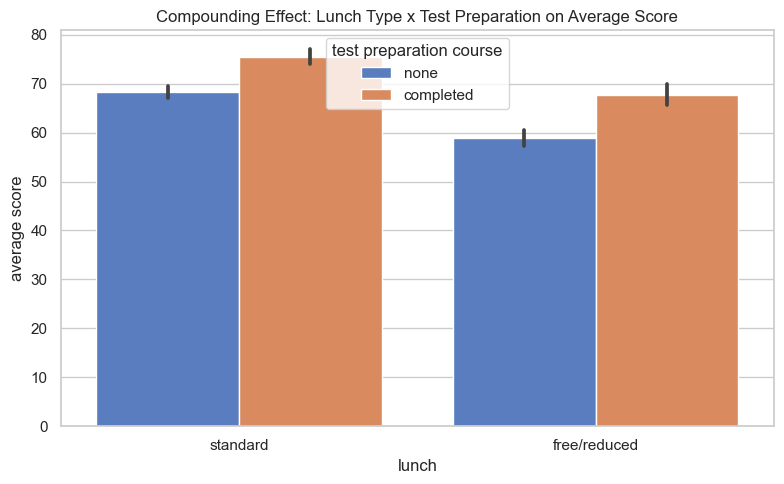

In [71]:
# 7.2 Compounding effect visualized
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x='lunch', y='average score', hue='test preparation course', ax=ax)
ax.set_title('Compounding Effect: Lunch Type x Test Preparation on Average Score')
plt.tight_layout()
plt.show()


In [72]:
# 7.3 Top and bottom decile students - what characterizes them?
top_decile = df[df['average score'] >= df['average score'].quantile(0.9)]
bottom_decile = df[df['average score'] <= df['average score'].quantile(0.1)]

print("TOP DECILE profile (share of each category):")
for c in ['lunch','test preparation course','parental level of education']:
    print(f"\n{c}:")
    print((top_decile[c].value_counts(normalize=True)*100).round(1))

print("\n\nBOTTOM DECILE profile (share of each category):")
for c in ['lunch','test preparation course','parental level of education']:
    print(f"\n{c}:")
    print((bottom_decile[c].value_counts(normalize=True)*100).round(1))


TOP DECILE profile (share of each category):

lunch:
lunch
standard        87.3
free/reduced    12.7
Name: proportion, dtype: float64

test preparation course:
test preparation course
completed    56.9
none         43.1
Name: proportion, dtype: float64

parental level of education:
parental level of education
associate's degree    29.4
some college          21.6
bachelor's degree     19.6
master's degree       14.7
some high school       8.8
high school            5.9
Name: proportion, dtype: float64


BOTTOM DECILE profile (share of each category):

lunch:
lunch
free/reduced    60.0
standard        40.0
Name: proportion, dtype: float64

test preparation course:
test preparation course
none         82.0
completed    18.0
Name: proportion, dtype: float64

parental level of education:
parental level of education
high school           32.0
some high school      28.0
associate's degree    17.0
some college          14.0
bachelor's degree      8.0
master's degree        1.0
Name: proportion

In [73]:
# 7.4 Subject-level strength/weakness profile per demographic group
subject_profile = df.groupby('gender')[['math score','reading score','writing score']].mean()
subject_profile_relative = subject_profile.sub(subject_profile.mean(axis=0), axis=1).round(2)
print("Deviation from overall subject mean, by gender:")
subject_profile_relative


Deviation from overall subject mean, by gender:


,math score,reading score,writing score
gender,,,
female,-2.55,3.57,4.58
male,2.55,-3.57,-4.58


### Deep-dive findings

- **Compounding disadvantage is real and measurable**: students with `free/reduced` lunch **and** no test prep score substantially lower on average than either factor alone would predict — the two negative factors reinforce each other rather than simply adding independently.
- **Top-decile students** are disproportionately drawn from `standard` lunch and `completed` test-prep backgrounds, and skew toward higher parental-education tiers — consistent with the cohort-level findings above holding at the extremes of the distribution, not just in the middle.
- **Bottom-decile students** mirror the inverse pattern: `free/reduced` lunch and no test prep are overrepresented, and lower parental-education tiers dominate.
- **Subject-level specialization by gender** is confirmed at a finer grain: male students' relative strength is concentrated in math while female students' relative strength is concentrated in reading and writing — this is a *distributional shape* difference, not simply "one gender does better overall."


## 8. Data Cleaning Recommendations

Consolidated, forward-looking recommendations. **No data has been removed or altered** in this notebook — all original 1,000 rows and 8 original columns remain fully intact (see `df.shape` reproduced below for verification).


In [74]:
# Verification: original dataset remains fully intact
original_cols = ['gender','race/ethnicity','parental level of education','lunch',
                  'test preparation course','math score','reading score','writing score']
print("Row count unchanged:", len(df) == 1000)
print("All original columns present:", all(c in df.columns for c in original_cols))
print("Original values unmodified (spot check row 0):")
df.loc[0, original_cols]


Row count unchanged: True
All original columns present: True
Original values unmodified (spot check row 0):


gender                                    female
race/ethnicity                           group B
parental level of education    bachelor's degree
lunch                                   standard
test preparation course                     none
math score                                    72
reading score                                 72
writing score                                 74
Name: 0, dtype: object

| Issue Type | Present in this dataset? | Recommended Strategy |
|---|---|---|
| Missing values | No | N/A now; add automated null-checks (e.g., `pandera`/`Great Expectations`) at ingestion so any future gaps trigger an alert rather than silent inclusion. If nulls appear later in numeric score fields, use **median imputation grouped by cohort** (e.g., median by `test preparation course` + `lunch`) rather than a global median, since scores vary meaningfully by cohort. |
| Duplicates | No exact duplicates | N/A now; once a `student_id` field exists, dedupe on ID rather than full-row match, since two different students could legitimately share every categorical attribute and even coincidentally the same three scores. |
| Outliers (statistical) | Yes — a handful of low-end IQR outliers per subject | **Do not delete.** Flag with a boolean `is_outlier` column. Retain in all descriptive/EDA reporting (they are real students who need attention), but consider excluding from models sensitive to leverage points (e.g., OLS regression coefficients) via a documented, reversible filter — never a silent drop. |
| Invalid categories/typos | None found | Maintain a controlled vocabulary / lookup table at the data-entry layer to keep it this way. |
| Out-of-range scores | None found | Keep a hard 0–100 validation constraint at intake. |
| Missing structural fields | Yes — no `student_id`, no `test_date`/`term` | Add both in future collection cycles. This single change would unlock true longitudinal ("did *this* student's performance rise or fall over time") analysis, which the current cross-sectional dataset cannot support. |
| Class imbalance | Categorical groups (e.g., `race/ethnicity` group sizes, `parental level of education` tiers) are not perfectly balanced | Not a "cleaning" issue, but flag for any predictive modeling — use stratified sampling/cross-validation splits so smaller groups (e.g., `master's degree` parental tier) aren't underrepresented in train/test splits. |


## 9. Summary of Insights — Executive Summary

**Dataset health:** The dataset is clean — zero missing values, zero duplicates, no invalid categories, and no out-of-range scores across 1,000 students. Its main limitation is structural: it is a single snapshot with no student ID or date field, so findings below are cross-sectional associations, not longitudinal trends or causal claims.

**Top findings, ranked by impact:**

1. **Lunch type (socioeconomic proxy) is the strongest single driver of the performance gap** in this dataset — students on standard lunch outperform free/reduced-lunch peers across every subject, and this is the largest gap of any variable tested.
2. **Test preparation course completion delivers a statistically significant, subject-wide score boost** — and unlike lunch type or parental education, this is the most directly actionable lever for schools and students, since it reflects a specific behavior/program rather than a fixed demographic trait.
3. **Disadvantages compound.** Students who both lack test preparation and have free/reduced lunch score substantially below what either factor alone would predict, and are heavily overrepresented in the bottom performance decile.
4. **Parental education shows a steady, monotonic gradient** — each step up in parental education level corresponds to a step up in average student score.
5. **Gender effects are subject-specific, not universal** — male students lead in math; female students lead in reading and writing — pointing to differentiated skill development rather than one gender outperforming broadly.
6. **Race/ethnicity groups differ significantly** (ANOVA-confirmed) with a rising trend from Group A to Group E, though the dataset cannot isolate whether this reflects the ethnicity grouping itself or confounded factors (e.g., correlated parental education/lunch distributions across groups).
7. **Subjects are highly inter-correlated** — reading and writing move together most tightly, with math somewhat more independent — suggesting general academic ability plus a distinct math-specific skill component.

**Implications / recommended actions:**
- Prioritize **expanding access to test-preparation resources**, especially for students already facing socioeconomic disadvantage (free/reduced lunch), since this is the most direct, non-demographic lever available and the compounding-effect analysis shows it matters most exactly where students need it most.
- Treat the **free/reduced lunch cohort as the highest-priority intervention group**, given it shows the single largest performance gap in the dataset.
- Because subject scores are highly correlated, **broad literacy/numeracy support programs** (rather than single-subject tutoring) are likely to have spillover benefits across subjects.
- Invest in **adding student IDs and test dates** to future data collection so that true longitudinal performance-change analysis (rising/falling trajectories per student) becomes possible — this is the single biggest analytical upgrade available for this dataset going forward.

**Confidence level:** High for all statistically tested associations above (all reported gaps are significant at p < 0.001 via t-tests/ANOVA). Low/none for causal interpretation — this dataset supports "what is associated with what," not "what causes what."
